# Proximal Policy Optimization (PPO) from scratch

Implementation of PPO on `CartPole-v1` with a separate policy and value network (actor-critic), a custom rollout loop, GAE advantages, and both clipped and unclipped surrogate objectives so we can compare them directly. At the end we render the trained policy so we can actually watch it balance the pole.

# Anuj Rajan Lalla (B22AI061)
# Abhinav Swami (B22AI003)
# Swaksh Patwari (B22AI065)

## Setup

In [1]:
# On Colab, uncomment this line the first time you run the notebook:
!pip install -q "gymnasium[classic-control]" imageio torch

In [2]:
import os
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")  # headless rendering on Colab

import math, time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

import gymnasium as gym
import imageio

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| gymnasium:", gym.__version__, "| torch:", torch.__version__)

device: cpu | gymnasium: 1.2.3 | torch: 2.10.0+cpu


## PPO

The policy gradient tells us to ascend $\mathbb{E}[\nabla \log \pi_\theta(a\mid s)\, A(s,a)]$. We would like to run several gradient steps on the same batch of data, but once $\theta$ drifts from the $\theta_{\text{old}}$ that generated the data we need importance sampling, which gives the surrogate

$$L^{\text{IS}}(\theta) = \mathbb{E}\big[r_t(\theta)\, A_t\big], \qquad r_t(\theta) = \frac{\pi_\theta(a_t\mid s_t)}{\pi_{\theta_{\text{old}}}(a_t\mid s_t)}.$$

This is the *unclipped* objective. It is unbiased at $\theta = \theta_{\text{old}}$ but the ratio can explode, so one lucky sample can push $\theta$ far from where the data is informative and training becomes unstable. PPO fixes this by clipping:

$$L^{\text{CLIP}}(\theta) = \mathbb{E}_t\!\left[\min\!\big(r_t(\theta) A_t,\; \text{clip}(r_t(\theta),\,1-\varepsilon,\,1+\varepsilon)\, A_t\big)\right].$$

The `min` is what makes this work: clipping only kicks in when it hurts the objective, so the policy is never rewarded for moving far from $\theta_{\text{old}}$. The full loss adds a value-function regression term and an optional entropy bonus:

$$L(\theta, \phi) = -L^{\text{CLIP}}(\theta) + c_v \| V_\phi(s_t) - \hat R_t \|^2 - c_e\, H[\pi_\theta(\cdot\mid s_t)].$$

Advantages come from Generalized Advantage Estimation: $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$, $\hat A_t = \sum_l (\gamma\lambda)^l \delta_{t+l}$. The parameter $\lambda$ interpolates between the 1-step TD residual ($\lambda=0$, low variance, biased) and the Monte-Carlo return ($\lambda=1$, unbiased, high variance). We use $\lambda = 0.95$.

## Actor-critic network

A small MLP with a shared tanh trunk and two heads: a policy head that outputs logits for a categorical distribution over the two actions, and a value head that outputs $V(s)$. The orthogonal init with a small gain on the policy head is a standard PPO detail that keeps the initial policy close to uniform.

`act()` is called during rollout collection (no gradients, samples an action). `evaluate()` is called during the update (with gradients, recomputes log probs and values under the current $\theta$).

In [3]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=64):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),  nn.Tanh(),
        )
        self.policy_head = nn.Linear(hidden, n_actions)
        self.value_head  = nn.Linear(hidden, 1)

        for m in self.shared:
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=math.sqrt(2))
                nn.init.zeros_(m.bias)
        nn.init.orthogonal_(self.policy_head.weight, gain=0.01)
        nn.init.zeros_(self.policy_head.bias)
        nn.init.orthogonal_(self.value_head.weight, gain=1.0)
        nn.init.zeros_(self.value_head.bias)

    def forward(self, obs):
        z = self.shared(obs)
        return self.policy_head(z), self.value_head(z).squeeze(-1)

    @torch.no_grad()
    def act(self, obs):
        logits, value = self.forward(obs)
        dist = Categorical(logits=logits)
        a = dist.sample()
        return a.item(), dist.log_prob(a).item(), value.item()

    def evaluate(self, obs, actions):
        logits, values = self.forward(obs)
        dist = Categorical(logits=logits)
        return dist.log_prob(actions), values, dist.entropy()

## Rollout collection

Run the current policy in the environment for a fixed number of timesteps and record everything we need. When an episode ends we reset and keep going, so a rollout usually contains pieces of several episodes. For the last (possibly mid-episode) state we also compute $V(s_T)$, which we need as the bootstrap target for GAE.

In [4]:
def collect_rollouts(env, model, n_steps):
    obs_buf, act_buf, logp_buf = [], [], []
    rew_buf, done_buf, val_buf = [], [], []
    ep_returns, ep_lengths = [], []

    obs, _ = env.reset()
    ep_ret, ep_len = 0.0, 0
    for _ in range(n_steps):
        obs_t = torch.as_tensor(obs, dtype=torch.float32)
        a, logp, v = model.act(obs_t)

        obs_buf.append(obs.copy()); act_buf.append(a)
        logp_buf.append(logp);      val_buf.append(v)

        obs, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated
        rew_buf.append(r); done_buf.append(done)
        ep_ret += r; ep_len += 1
        if done:
            ep_returns.append(ep_ret); ep_lengths.append(ep_len)
            obs, _ = env.reset()
            ep_ret, ep_len = 0.0, 0

    with torch.no_grad():
        _, last_val = model.forward(torch.as_tensor(obs, dtype=torch.float32))

    return {
        "obs":      np.asarray(obs_buf,  dtype=np.float32),
        "acts":     np.asarray(act_buf,  dtype=np.int64),
        "logps":    np.asarray(logp_buf, dtype=np.float32),
        "rews":     np.asarray(rew_buf,  dtype=np.float32),
        "dones":    np.asarray(done_buf, dtype=np.float32),
        "vals":     np.asarray(val_buf,  dtype=np.float32),
        "last_val": float(last_val.item()),
        "ep_returns": ep_returns,
        "ep_lengths": ep_lengths,
    }

## Advantages with GAE

Sweep backwards through the buffer, accumulating discounted TD residuals. The `(1 - done)` mask correctly zeros out bootstrapping across episode boundaries. The returns-to-go used as the value-regression target are just $\hat R_t = \hat A_t + V(s_t)$.

In [5]:
def compute_gae(rews, vals, dones, last_val, gamma=0.99, lam=0.95):
    T = len(rews)
    adv = np.zeros(T, dtype=np.float32)
    gae = 0.0
    next_val = last_val
    for t in reversed(range(T)):
        non_terminal = 1.0 - dones[t]
        delta = rews[t] + gamma * next_val * non_terminal - vals[t]
        gae   = delta + gamma * lam * non_terminal * gae
        adv[t] = gae
        next_val = vals[t]
    returns = adv + vals
    return adv, returns

## The two objectives

This is the one place clipped and unclipped PPO differ. Everything else (network, rollout collection, GAE, value loss, optimizer step) is identical. We keep both in a single function so the comparison is literally a boolean flag.

In [6]:
def policy_objective(ratio, adv, clip_eps, use_clip):
    """Per-sample policy loss to minimize."""
    if use_clip:
        unclipped = ratio * adv
        clipped   = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * adv
        return -torch.min(unclipped, clipped)
    return -(ratio * adv)

## PPO update step

Given a rollout, run several epochs of minibatch updates. Each minibatch recomputes log probs and values under the current $\theta$, forms the ratio against the frozen old log probs, and descends on $L_\pi + c_v L_V - c_e H$. Advantages are standardized per rollout, which does not change the population gradient but drops its variance substantially. Gradients are clipped to norm 0.5.

We track three diagnostics: approximate KL from old to new policy (how far each update moved us), clip fraction (share of samples where $|r_t - 1| > \varepsilon$), and value loss.

In [7]:
def ppo_update(model, optimizer, batch, *,
               clip_eps=0.2, n_epochs=10, minibatch=64,
               vf_coef=0.5, ent_coef=0.0, use_clip=True, max_grad_norm=0.5):
    obs       = torch.as_tensor(batch["obs"])
    acts      = torch.as_tensor(batch["acts"])
    old_logps = torch.as_tensor(batch["logps"])
    advs      = torch.as_tensor(batch["advs"])
    rets      = torch.as_tensor(batch["rets"])

    advs = (advs - advs.mean()) / (advs.std() + 1e-8)  # per-rollout standardization

    n = obs.shape[0]; idx = np.arange(n)
    stats = {"pi_loss": [], "v_loss": [], "ent": [], "kl": [], "clip_frac": []}

    for _ in range(n_epochs):
        np.random.shuffle(idx)
        for s in range(0, n, minibatch):
            b = idx[s:s + minibatch]
            mb_obs, mb_acts    = obs[b], acts[b]
            mb_oldlogp, mb_adv = old_logps[b], advs[b]
            mb_ret             = rets[b]

            logps, values, entropy = model.evaluate(mb_obs, mb_acts)
            ratio = torch.exp(logps - mb_oldlogp)

            pi_loss = policy_objective(ratio, mb_adv, clip_eps, use_clip).mean()
            v_loss  = (values - mb_ret).pow(2).mean()
            loss    = pi_loss + vf_coef * v_loss - ent_coef * entropy.mean()

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

            with torch.no_grad():
                kl = (mb_oldlogp - logps).mean().item()
                clip_frac = (((ratio - 1.0).abs() > clip_eps).float().mean().item()
                             if use_clip else 0.0)

            stats["pi_loss"].append(pi_loss.item())
            stats["v_loss"].append(v_loss.item())
            stats["ent"].append(entropy.mean().item())
            stats["kl"].append(kl)
            stats["clip_frac"].append(clip_frac)

    return {k: float(np.mean(v)) for k, v in stats.items()}

## Training loop

Collect a rollout, compute advantages, run PPO updates, repeat until the step budget is used up.

In [8]:
def train_ppo(env_name="CartPole-v1", *,
              total_steps=50_000, steps_per_rollout=1024,
              lr=3e-4, gamma=0.99, lam=0.95,
              clip_eps=0.2, n_epochs=10, minibatch=64,
              ent_coef=0.0, use_clip=True, seed=0, verbose=True):

    torch.manual_seed(seed); np.random.seed(seed)
    env = gym.make(env_name)
    env.reset(seed=seed); env.action_space.seed(seed)

    model = ActorCritic(env.observation_space.shape[0], env.action_space.n)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {k: [] for k in
               ["iter", "steps", "mean_return", "max_return",
                "pi_loss", "v_loss", "ent", "kl", "clip_frac"]}

    steps_done, it = 0, 0
    while steps_done < total_steps:
        batch = collect_rollouts(env, model, steps_per_rollout)
        advs, rets = compute_gae(batch["rews"], batch["vals"], batch["dones"],
                                 batch["last_val"], gamma=gamma, lam=lam)
        batch["advs"], batch["rets"] = advs, rets

        upd = ppo_update(model, optimizer, batch,
                         clip_eps=clip_eps, n_epochs=n_epochs,
                         minibatch=minibatch, ent_coef=ent_coef, use_clip=use_clip)

        steps_done += steps_per_rollout; it += 1
        mean_ret = float(np.mean(batch["ep_returns"])) if batch["ep_returns"] else 0.0
        max_ret  = float(np.max(batch["ep_returns"]))  if batch["ep_returns"] else 0.0

        history["iter"].append(it); history["steps"].append(steps_done)
        history["mean_return"].append(mean_ret); history["max_return"].append(max_ret)
        for k in ("pi_loss", "v_loss", "ent", "kl", "clip_frac"):
            history[k].append(upd[k])

        if verbose and (it % 5 == 0 or it == 1):
            tag = "clip" if use_clip else "NOCLIP"
            print(f"[{tag}] iter {it:3d} | steps {steps_done:6d} "
                  f"| R={mean_ret:6.1f} | pi_loss={upd['pi_loss']:+.4f} "
                  f"| v_loss={upd['v_loss']:6.2f} | KL={upd['kl']:+.4f} "
                  f"| clip_frac={upd['clip_frac']:.3f}")

    env.close()
    return model, history

## Experiments

A single RL seed is noisy, so we run three seeds per configuration and average. The same three seeds are used for both clipped and unclipped so the two agents start from matching initial conditions. CartPole-v1's max episodic return is 500.

In [9]:
CONFIG = dict(
    env_name="CartPole-v1",
    total_steps=60_000,
    steps_per_rollout=1024,
    lr=3e-4, gamma=0.99, lam=0.95,
    clip_eps=0.2, n_epochs=10, minibatch=64, ent_coef=0.0,
)
SEEDS = [0, 1, 2]

In [10]:
runs_clip = []
t0 = time.time()
for s in SEEDS:
    print(f"\n--- CLIPPED, seed={s} ---")
    m, h = train_ppo(**CONFIG, use_clip=True, seed=s, verbose=(s == 0))
    runs_clip.append({"seed": s, "model": m, "hist": h})
print(f"\nwall-time: {time.time() - t0:.1f}s")


--- CLIPPED, seed=0 ---
[clip] iter   1 | steps   1024 | R=  20.3 | pi_loss=-0.0184 | v_loss= 66.94 | KL=+0.0132 | clip_frac=0.089
[clip] iter   5 | steps   5120 | R=  24.9 | pi_loss=-0.0229 | v_loss= 35.94 | KL=+0.0156 | clip_frac=0.210
[clip] iter  10 | steps  10240 | R=  46.4 | pi_loss=-0.0083 | v_loss= 86.15 | KL=+0.0249 | clip_frac=0.196
[clip] iter  15 | steps  15360 | R=  35.6 | pi_loss=+0.0048 | v_loss=109.34 | KL=+0.1020 | clip_frac=0.366
[clip] iter  20 | steps  20480 | R= 140.9 | pi_loss=+0.0195 | v_loss= 45.95 | KL=+0.0260 | clip_frac=0.276
[clip] iter  25 | steps  25600 | R=  29.3 | pi_loss=+0.0417 | v_loss=203.05 | KL=+0.1994 | clip_frac=0.400
[clip] iter  30 | steps  30720 | R= 206.5 | pi_loss=+0.0392 | v_loss= 17.65 | KL=+0.0263 | clip_frac=0.206
[clip] iter  35 | steps  35840 | R= 169.0 | pi_loss=+0.0172 | v_loss= 59.70 | KL=+0.0286 | clip_frac=0.252
[clip] iter  40 | steps  40960 | R= 139.6 | pi_loss=+0.0175 | v_loss= 11.53 | KL=+0.0214 | clip_frac=0.303
[clip] iter 

In [11]:
runs_noclip = []
t0 = time.time()
for s in SEEDS:
    print(f"\n--- UNCLIPPED, seed={s} ---")
    m, h = train_ppo(**CONFIG, use_clip=False, seed=s, verbose=(s == 0))
    runs_noclip.append({"seed": s, "model": m, "hist": h})
print(f"\nwall-time: {time.time() - t0:.1f}s")


--- UNCLIPPED, seed=0 ---
[NOCLIP] iter   1 | steps   1024 | R=  20.3 | pi_loss=-0.0323 | v_loss= 66.94 | KL=+0.0280 | clip_frac=0.000
[NOCLIP] iter   5 | steps   5120 | R=  23.1 | pi_loss=-0.1024 | v_loss= 28.86 | KL=+0.2085 | clip_frac=0.000
[NOCLIP] iter  10 | steps  10240 | R=  64.3 | pi_loss=-0.0319 | v_loss= 74.67 | KL=+0.0545 | clip_frac=0.000
[NOCLIP] iter  15 | steps  15360 | R=  41.2 | pi_loss=-0.0418 | v_loss=130.61 | KL=+0.1135 | clip_frac=0.000
[NOCLIP] iter  20 | steps  20480 | R= 203.6 | pi_loss=+0.0168 | v_loss= 30.25 | KL=+0.0328 | clip_frac=0.000
[NOCLIP] iter  25 | steps  25600 | R= 149.2 | pi_loss=+0.0103 | v_loss= 30.09 | KL=+0.0436 | clip_frac=0.000
[NOCLIP] iter  30 | steps  30720 | R=  13.9 | pi_loss=-0.1435 | v_loss=295.15 | KL=+1.2052 | clip_frac=0.000
[NOCLIP] iter  35 | steps  35840 | R=  82.3 | pi_loss=-0.0410 | v_loss= 79.34 | KL=+0.0703 | clip_frac=0.000
[NOCLIP] iter  40 | steps  40960 | R= 147.0 | pi_loss=-0.0064 | v_loss= 33.22 | KL=+0.0890 | clip_fra

## Learning curves

Per-seed returns as thin lines, mean across seeds as a thick line with a $\pm 1$ std band.

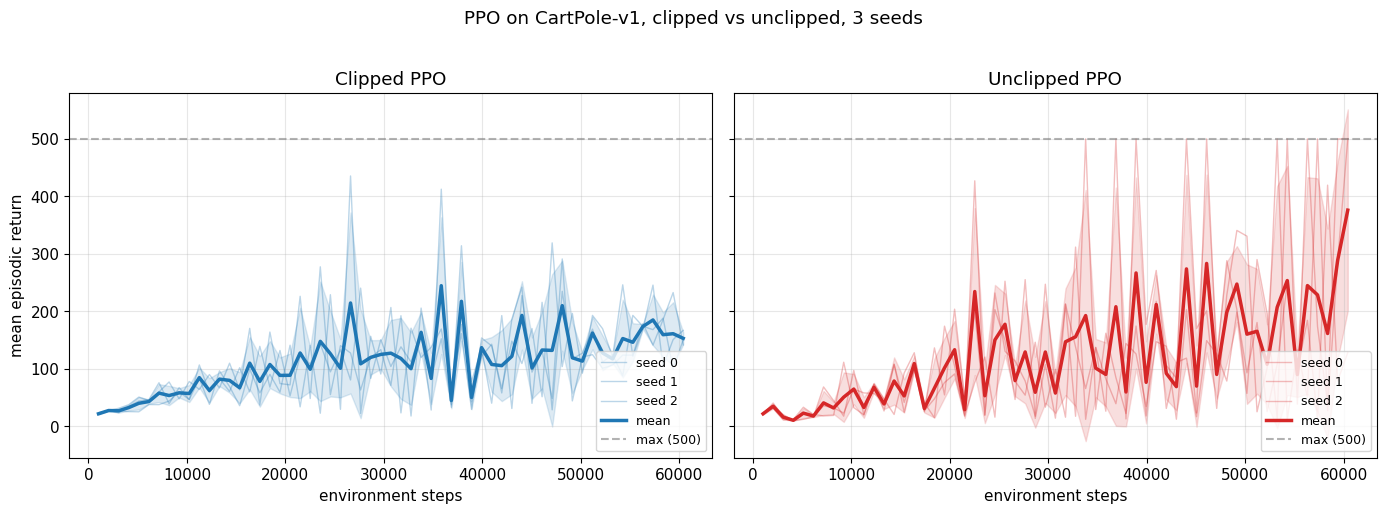

In [12]:
def stack_returns(runs):
    L = min(len(r["hist"]["mean_return"]) for r in runs)
    return (np.array(runs[0]["hist"]["steps"][:L]),
            np.array([r["hist"]["mean_return"][:L] for r in runs]))

steps_c, R_clip   = stack_returns(runs_clip)
steps_u, R_noclip = stack_returns(runs_noclip)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (steps, R, title, color) in zip(
        axes,
        [(steps_c, R_clip,   "Clipped PPO",   "tab:blue"),
         (steps_u, R_noclip, "Unclipped PPO", "tab:red")]):
    for i in range(R.shape[0]):
        ax.plot(steps, R[i], color=color, alpha=0.3, lw=1, label=f"seed {SEEDS[i]}")
    mean, std = R.mean(0), R.std(0)
    ax.plot(steps, mean, color=color, lw=2.5, label="mean")
    ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.15)
    ax.axhline(500, ls="--", color="gray", alpha=0.6, label="max (500)")
    ax.set_xlabel("environment steps"); ax.set_title(title)
    ax.grid(alpha=0.3); ax.legend(loc="lower right", fontsize=9)
axes[0].set_ylabel("mean episodic return")
plt.suptitle("PPO on CartPole-v1, clipped vs unclipped, 3 seeds", y=1.02)
plt.tight_layout(); plt.show()

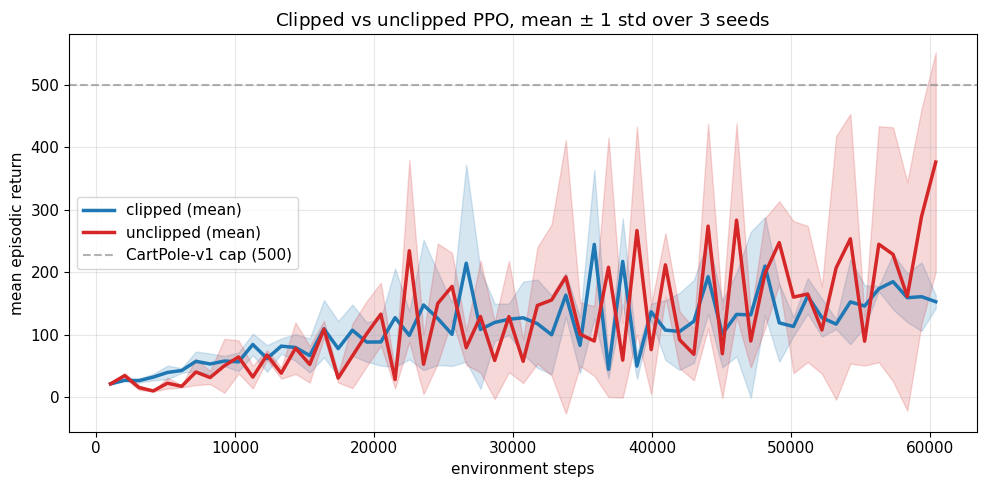


metric                                 clipped     unclipped
------------------------------------------------------------
final mean return                        152.8         376.0
best mean return                         244.5         376.0
across-seed std at end                    10.4         175.4
iteration-wise std (mean)                 42.4          76.2


In [13]:
plt.figure(figsize=(10, 5))
mc, sc = R_clip.mean(0),   R_clip.std(0)
mu, su = R_noclip.mean(0), R_noclip.std(0)
plt.plot(steps_c, mc, color="tab:blue", lw=2.5, label="clipped (mean)")
plt.fill_between(steps_c, mc - sc, mc + sc, color="tab:blue", alpha=0.18)
plt.plot(steps_u, mu, color="tab:red",  lw=2.5, label="unclipped (mean)")
plt.fill_between(steps_u, mu - su, mu + su, color="tab:red",  alpha=0.18)
plt.axhline(500, ls="--", color="gray", alpha=0.6, label="CartPole-v1 cap (500)")
plt.xlabel("environment steps"); plt.ylabel("mean episodic return")
plt.title("Clipped vs unclipped PPO, mean $\\pm$ 1 std over 3 seeds")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"\n{'metric':<32}{'clipped':>14}{'unclipped':>14}")
print("-" * 60)
print(f"{'final mean return':<32}{mc[-1]:>14.1f}{mu[-1]:>14.1f}")
print(f"{'best mean return':<32}{mc.max():>14.1f}{mu.max():>14.1f}")
print(f"{'across-seed std at end':<32}{sc[-1]:>14.1f}{su[-1]:>14.1f}")
print(f"{'iteration-wise std (mean)':<32}{sc.mean():>14.1f}{su.mean():>14.1f}")

With matched hyperparameters, the clipped agent produces a tight across-seed band: the three seeds stay close to one another with an across-seed standard deviation of about 10 at the final iteration, though the mean return sits around 150 rather than hitting the 500-step cap in this 60k-step budget. The unclipped agent reaches a higher across-seed mean (around 375) but with an across-seed standard deviation of about 175, more than sixteen times larger. Looking at the seed-0 training log makes the pattern concrete: the unclipped run swings between $R=500$ runs (iterations 45 and 55) and a collapse to $R\approx 14$ at iteration 30 that coincides with a KL spike of roughly $1.2$, whereas the clipped run stays in a much narrower $R \in [30, 210]$ band throughout. This is the textbook failure mode of the importance-sampled surrogate: a single sample with a large ratio and positive advantage can push the policy into a region where the old data is no longer informative. So the comparison here is not about peak return, it is about predictability: clipping trades some upside for a dramatically tighter distribution across seeds, which is usually what we want.

## Diagnostics

Why do the two agents behave differently? The KL panel shows how far each update moved the policy: clipped PPO keeps this in a narrow band around $0.02$, while the unclipped surrogate produces much larger and noisier values, including the $\approx 1.2$ spike we already saw in the seed-0 log. The clip-fraction panel shows the share of samples the clip was actively bounding, which for the clipped run typically sits in the $10$ to $40$ percent range depending on how aggressive the update happens to be (zero for the unclipped run by construction). The value-loss panel is similar for both, which makes sense because the value head is trained identically in both setups, so the performance gap has to come from the policy objective itself.

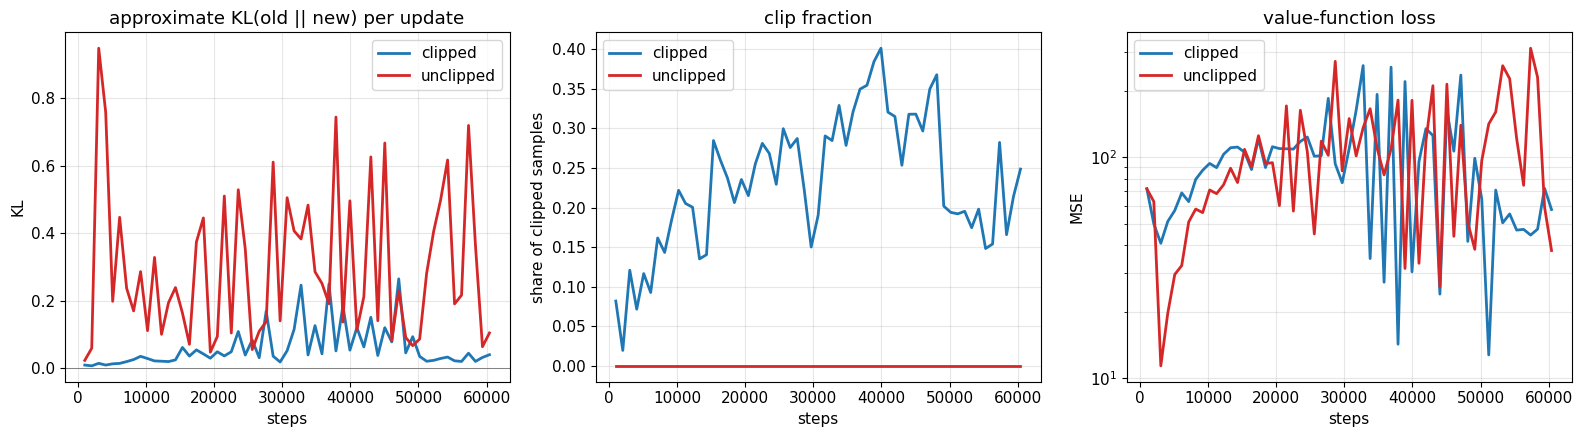

In [14]:
def avg_metric(runs, key):
    L = min(len(r["hist"][key]) for r in runs)
    return (np.array([r["hist"][key][:L] for r in runs]).mean(0),
            runs[0]["hist"]["steps"][:L])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for runs, color, label in [(runs_clip, "tab:blue", "clipped"),
                           (runs_noclip, "tab:red", "unclipped")]:
    kl_m, st  = avg_metric(runs, "kl")
    cf_m, _   = avg_metric(runs, "clip_frac")
    vl_m, _   = avg_metric(runs, "v_loss")
    axes[0].plot(st, kl_m, color=color, lw=2, label=label)
    axes[1].plot(st, cf_m, color=color, lw=2, label=label)
    axes[2].plot(st, vl_m, color=color, lw=2, label=label)

axes[0].set_title("approximate KL(old || new) per update")
axes[0].set_xlabel("steps"); axes[0].set_ylabel("KL")
axes[0].axhline(0.0, color="gray", lw=0.7); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].set_title("clip fraction")
axes[1].set_xlabel("steps"); axes[1].set_ylabel("share of clipped samples")
axes[1].grid(alpha=0.3); axes[1].legend()

axes[2].set_title("value-function loss")
axes[2].set_xlabel("steps"); axes[2].set_ylabel("MSE")
axes[2].set_yscale("log"); axes[2].grid(alpha=0.3, which="both"); axes[2].legend()

plt.tight_layout(); plt.show()

## Hyperparameter analysis

All sweeps below use a single seed (seed 0) and a shorter horizon (40k steps) to keep runtime modest. The clipped objective is used throughout. A small helper runs one configuration and returns the history.

In [15]:
def sweep_run(override, total_steps=40_000, seed=0):
    cfg = dict(CONFIG); cfg.update(override); cfg["total_steps"] = total_steps
    _, h = train_ppo(**cfg, use_clip=True, seed=seed, verbose=False)
    return h

def plot_sweep(runs_dict, param_name, title_ret, title_kl=None, log_y=False):
    """Plot return (and optionally KL) curves across a hyperparameter sweep."""
    ncols = 2 if title_kl else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 4.5), squeeze=False)
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(runs_dict)))
    for (val, h), c in zip(runs_dict.items(), colors):
        axes[0, 0].plot(h["steps"], h["mean_return"], color=c, lw=2,
                        label=f"{param_name}={val}")
    axes[0, 0].axhline(500, ls="--", color="gray", alpha=0.6)
    axes[0, 0].set_xlabel("steps"); axes[0, 0].set_ylabel("mean episodic return")
    axes[0, 0].set_title(title_ret); axes[0, 0].grid(alpha=0.3); axes[0, 0].legend()
    if log_y: axes[0, 0].set_yscale("symlog")
    if title_kl:
        for (val, h), c in zip(runs_dict.items(), colors):
            axes[0, 1].plot(h["steps"], h["kl"], color=c, lw=2, label=f"{param_name}={val}")
        axes[0, 1].set_xlabel("steps"); axes[0, 1].set_ylabel("KL(old || new)")
        axes[0, 1].set_title(title_kl); axes[0, 1].grid(alpha=0.3); axes[0, 1].legend()
    plt.tight_layout(); plt.show()

### Effect of the clip parameter $\varepsilon$

Smaller $\varepsilon$ means tighter trust region, more stable but slower learning. Larger $\varepsilon$ means the clip rarely fires, so the objective approaches the noisy unclipped one.

In [16]:
eps_values = [0.05, 0.1, 0.2, 0.5]
eps_runs = {}
for eps in eps_values:
    eps_runs[eps] = sweep_run({"clip_eps": eps})
    print(f"clip_eps={eps}: final mean return = {eps_runs[eps]['mean_return'][-1]:.1f}")

clip_eps=0.05: final mean return = 161.3
clip_eps=0.1: final mean return = 58.5
clip_eps=0.2: final mean return = 139.6
clip_eps=0.5: final mean return = 206.5


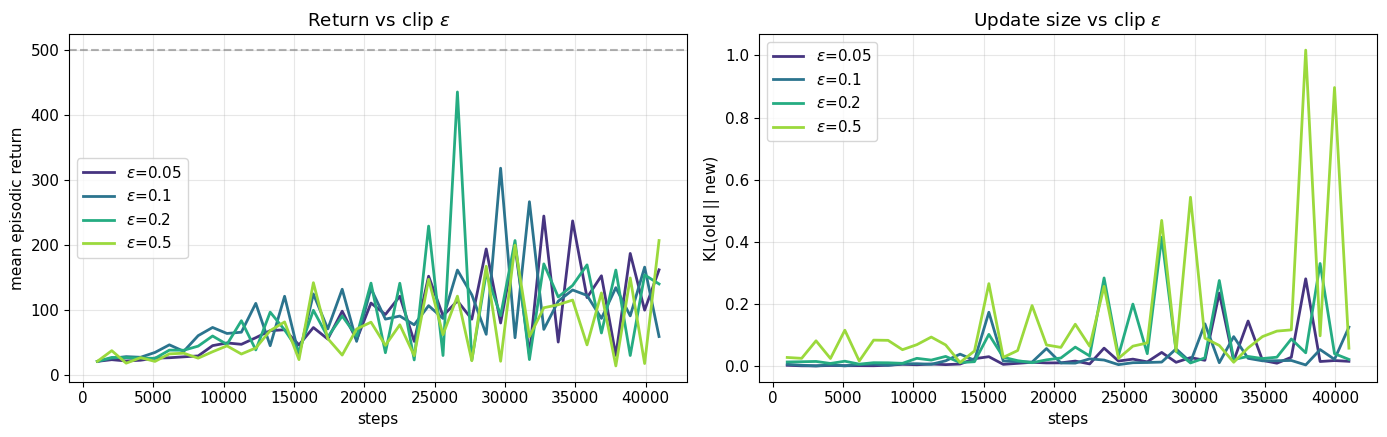

In [17]:
plot_sweep(eps_runs, "$\\varepsilon$",
           "Return vs clip $\\varepsilon$",
           "Update size vs clip $\\varepsilon$")

### Effect of GAE $\lambda$

$\lambda$ controls the bias-variance tradeoff in the advantage estimator. $\lambda = 0$ is the 1-step TD residual (low variance, high bias, highly dependent on a good $V_\phi$). $\lambda = 1$ is the Monte-Carlo advantage (unbiased but high variance). Intermediate values like $0.95$ are the standard PPO choice.

In [18]:
lam_values = [0.0, 0.5, 0.95, 1.0]
lam_runs = {}
for lam in lam_values:
    lam_runs[lam] = sweep_run({"lam": lam})
    print(f"lambda={lam}: final mean return = {lam_runs[lam]['mean_return'][-1]:.1f}")

lambda=0.0: final mean return = 188.8
lambda=0.5: final mean return = 117.6
lambda=0.95: final mean return = 139.6
lambda=1.0: final mean return = 84.2


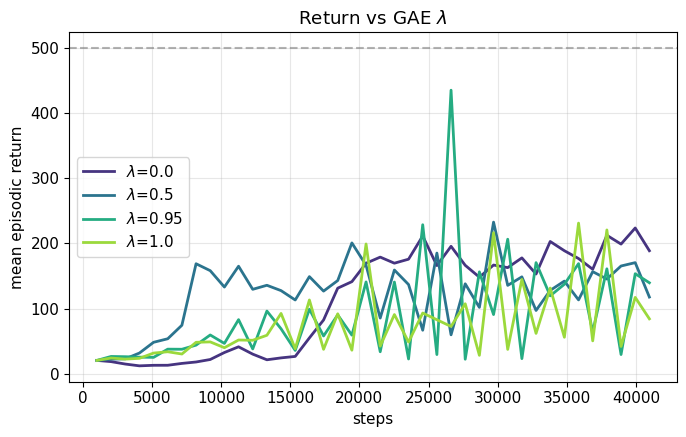

In [19]:
plot_sweep(lam_runs, "$\\lambda$",
           "Return vs GAE $\\lambda$")

### Effect of learning rate

Adam learning rate for the joint actor-critic optimizer. Too small and learning is slow. Too large and updates overshoot into regions the data does not support, amplified by running multiple epochs on each batch.

In [20]:
lr_values = [1e-4, 3e-4, 1e-3, 3e-3]
lr_runs = {}
for lr in lr_values:
    lr_runs[lr] = sweep_run({"lr": lr})
    print(f"lr={lr}: final mean return = {lr_runs[lr]['mean_return'][-1]:.1f}")

lr=0.0001: final mean return = 88.6
lr=0.0003: final mean return = 139.6
lr=0.001: final mean return = 330.0
lr=0.003: final mean return = 500.0


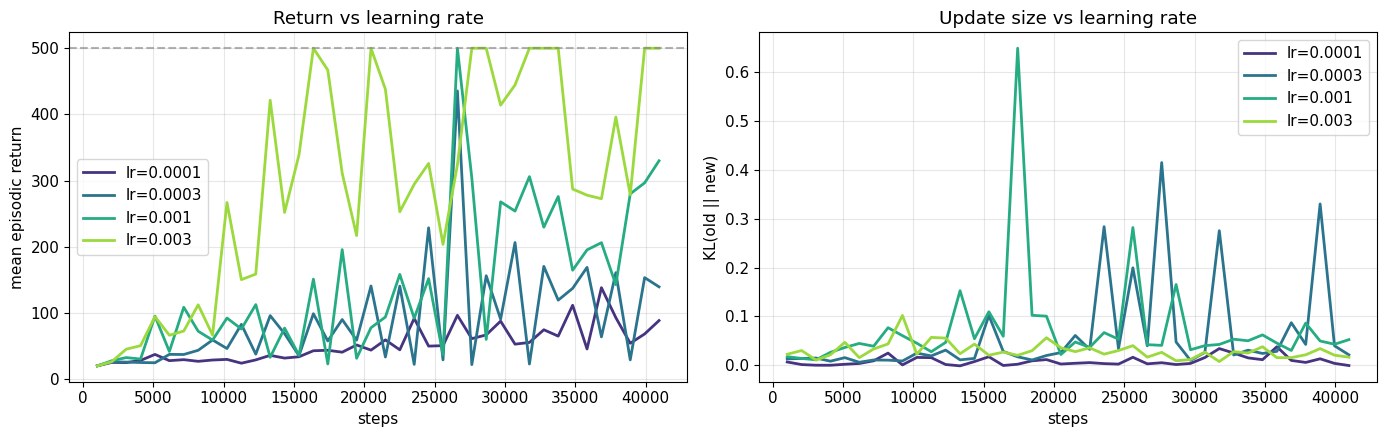

In [21]:
plot_sweep(lr_runs, "lr",
           "Return vs learning rate",
           "Update size vs learning rate")

### Effect of PPO epochs per rollout

How many passes we make over each rollout. One epoch is essentially vanilla policy gradient (each sample used once). Many epochs amortize expensive rollouts but push the policy further from $\theta_{\text{old}}$ on every pass, so the clip starts firing harder and harder.

In [22]:
epoch_values = [1, 4, 10, 20]
epoch_runs = {}
for ne in epoch_values:
    epoch_runs[ne] = sweep_run({"n_epochs": ne})
    print(f"n_epochs={ne}: final mean return = {epoch_runs[ne]['mean_return'][-1]:.1f}")

n_epochs=1: final mean return = 35.2
n_epochs=4: final mean return = 58.8
n_epochs=10: final mean return = 139.6
n_epochs=20: final mean return = 247.0


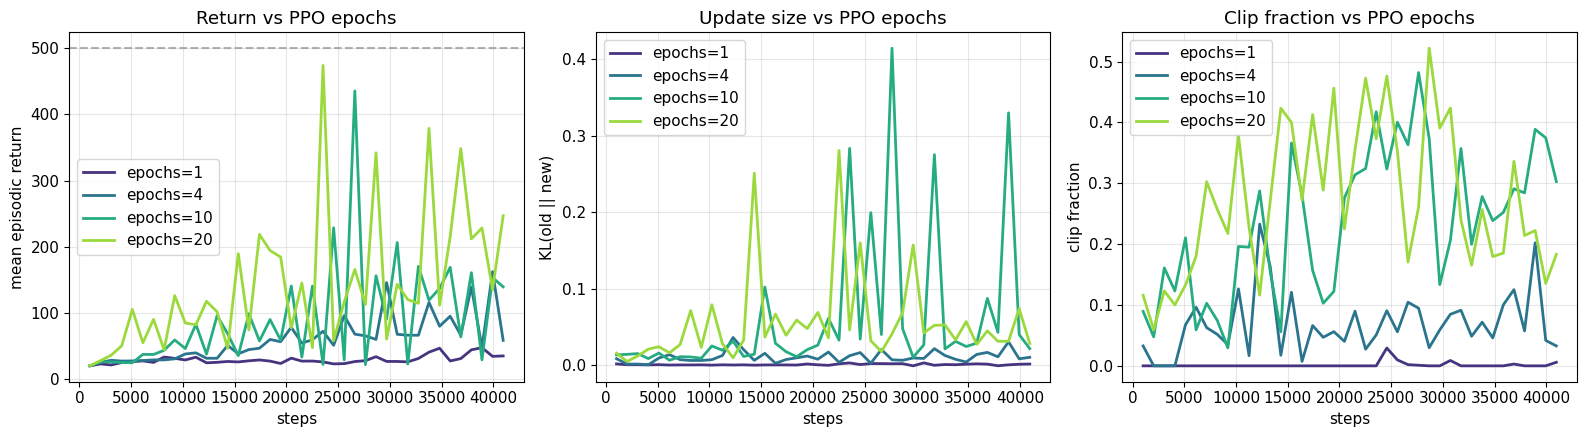

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(epoch_values)))
for (ne, h), c in zip(epoch_runs.items(), colors):
    axes[0].plot(h["steps"], h["mean_return"], color=c, lw=2, label=f"epochs={ne}")
    axes[1].plot(h["steps"], h["kl"],          color=c, lw=2, label=f"epochs={ne}")
    axes[2].plot(h["steps"], h["clip_frac"],   color=c, lw=2, label=f"epochs={ne}")

axes[0].axhline(500, ls="--", color="gray", alpha=0.6)
axes[0].set_xlabel("steps"); axes[0].set_ylabel("mean episodic return")
axes[0].set_title("Return vs PPO epochs"); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].set_xlabel("steps"); axes[1].set_ylabel("KL(old || new)")
axes[1].set_title("Update size vs PPO epochs"); axes[1].grid(alpha=0.3); axes[1].legend()

axes[2].set_xlabel("steps"); axes[2].set_ylabel("clip fraction")
axes[2].set_title("Clip fraction vs PPO epochs"); axes[2].grid(alpha=0.3); axes[2].legend()
plt.tight_layout(); plt.show()

### Effect of entropy coefficient

Adding $-c_e H[\pi]$ to the loss rewards the policy for being uncertain, which helps it keep exploring. On CartPole the optimal policy is nearly deterministic so a large entropy bonus actively hurts, but a small amount can stabilize the early phase of training.

In [24]:
ent_values = [0.0, 0.01, 0.05, 0.1]
ent_runs = {}
for ec in ent_values:
    ent_runs[ec] = sweep_run({"ent_coef": ec})
    print(f"ent_coef={ec}: final mean return = {ent_runs[ec]['mean_return'][-1]:.1f}")

ent_coef=0.0: final mean return = 139.6
ent_coef=0.01: final mean return = 110.7
ent_coef=0.05: final mean return = 33.6
ent_coef=0.1: final mean return = 78.5


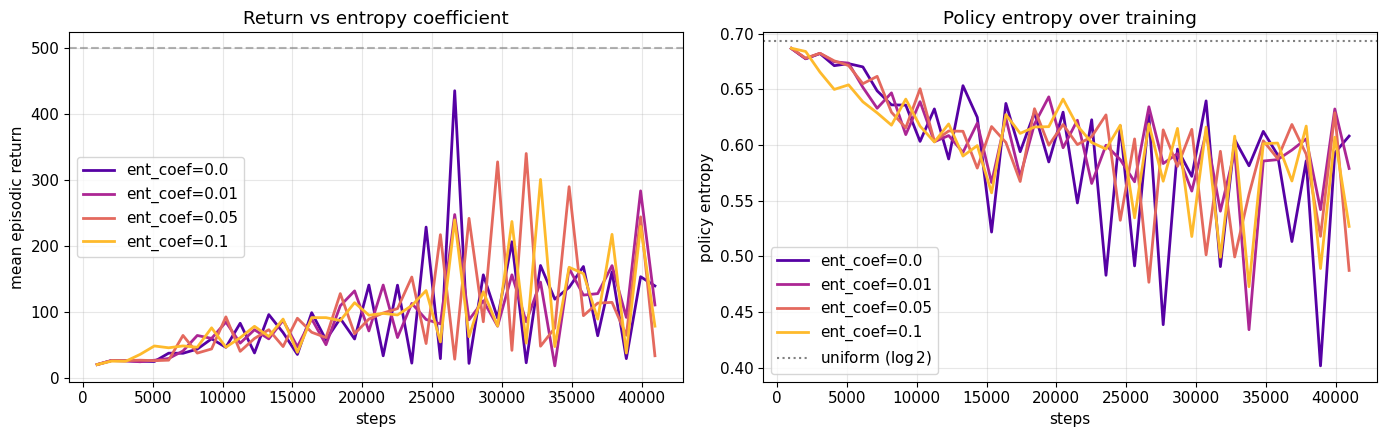

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(ent_values)))
for (ec, h), c in zip(ent_runs.items(), colors):
    axes[0].plot(h["steps"], h["mean_return"], color=c, lw=2, label=f"ent_coef={ec}")
    axes[1].plot(h["steps"], h["ent"],         color=c, lw=2, label=f"ent_coef={ec}")

axes[0].axhline(500, ls="--", color="gray", alpha=0.6)
axes[0].set_xlabel("steps"); axes[0].set_ylabel("mean episodic return")
axes[0].set_title("Return vs entropy coefficient"); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].set_xlabel("steps"); axes[1].set_ylabel("policy entropy")
axes[1].axhline(np.log(2), ls=":", color="gray", label="uniform ($\\log 2$)")
axes[1].set_title("Policy entropy over training"); axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()

### Hyperparameter summary table

In [26]:
def final_of(runs_dict): return {k: v["mean_return"][-1] for k, v in runs_dict.items()}
rows = [
    ("clip_eps",   final_of(eps_runs)),
    ("lambda",     final_of(lam_runs)),
    ("lr",         final_of(lr_runs)),
    ("n_epochs",   final_of(epoch_runs)),
    ("ent_coef",   final_of(ent_runs)),
]
print(f"{'parameter':<12} {'setting':>12} {'final return':>14}")
print("-" * 42)
for name, d in rows:
    for k, v in d.items():
        print(f"{name:<12} {str(k):>12} {v:>14.1f}")
    print()

parameter         setting   final return
------------------------------------------
clip_eps             0.05          161.3
clip_eps              0.1           58.5
clip_eps              0.2          139.6
clip_eps              0.5          206.5

lambda                0.0          188.8
lambda                0.5          117.6
lambda               0.95          139.6
lambda                1.0           84.2

lr                 0.0001           88.6
lr                 0.0003          139.6
lr                  0.001          330.0
lr                  0.003          500.0

n_epochs                1           35.2
n_epochs                4           58.8
n_epochs               10          139.6
n_epochs               20          247.0

ent_coef              0.0          139.6
ent_coef             0.01          110.7
ent_coef             0.05           33.6
ent_coef              0.1           78.5



## Episode length evolution

For each clipped-PPO seed we already have the list of episodic returns per rollout. On CartPole, return equals episode length (reward is +1 per step), so we can visualize learning as a shift in the distribution of episode lengths over training. Early rollouts are dominated by short episodes (the pole falls fast); later rollouts are longer on average, though at a 60k-step budget the mean episode length per rollout does not consistently sit at the 500-step cap, and the per-seed curves visibly climb and drop back multiple times rather than converging monotonically.

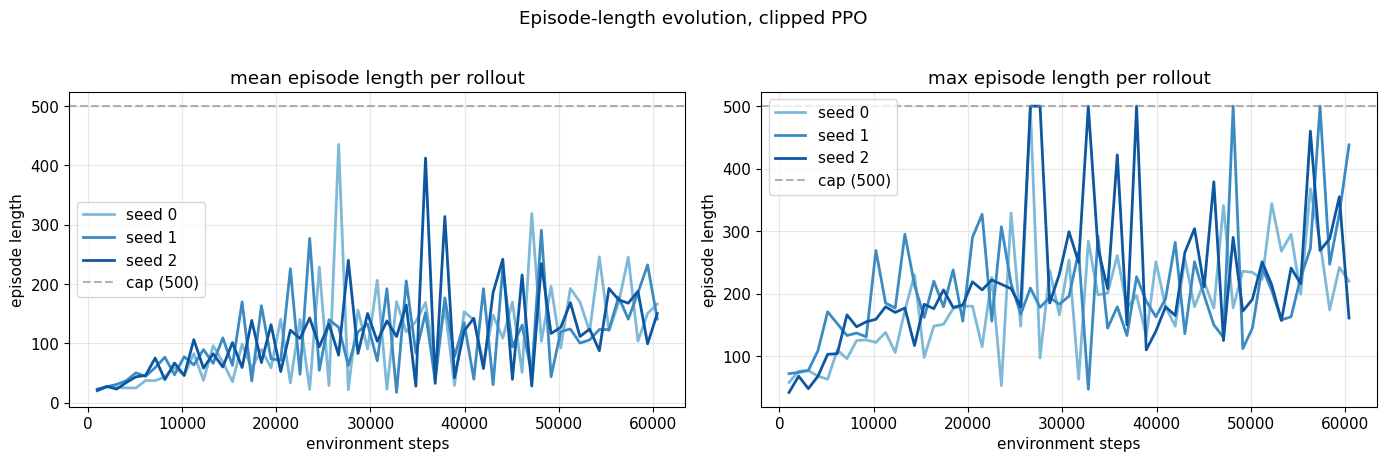

In [27]:
# Per-iteration mean and max returns for each clipped seed
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for run, color in zip(runs_clip, plt.cm.Blues(np.linspace(0.45, 0.85, len(runs_clip)))):
    h = run["hist"]
    axes[0].plot(h["steps"], h["mean_return"], color=color, lw=2,
                 label=f"seed {run['seed']}")
    axes[1].plot(h["steps"], h["max_return"],  color=color, lw=2,
                 label=f"seed {run['seed']}")
for ax, title in zip(axes, ["mean episode length per rollout",
                            "max episode length per rollout"]):
    ax.axhline(500, ls="--", color="gray", alpha=0.6, label="cap (500)")
    ax.set_xlabel("environment steps"); ax.set_ylabel("episode length")
    ax.set_title(title); ax.grid(alpha=0.3); ax.legend()
plt.suptitle("Episode-length evolution, clipped PPO", y=1.02)
plt.tight_layout(); plt.show()

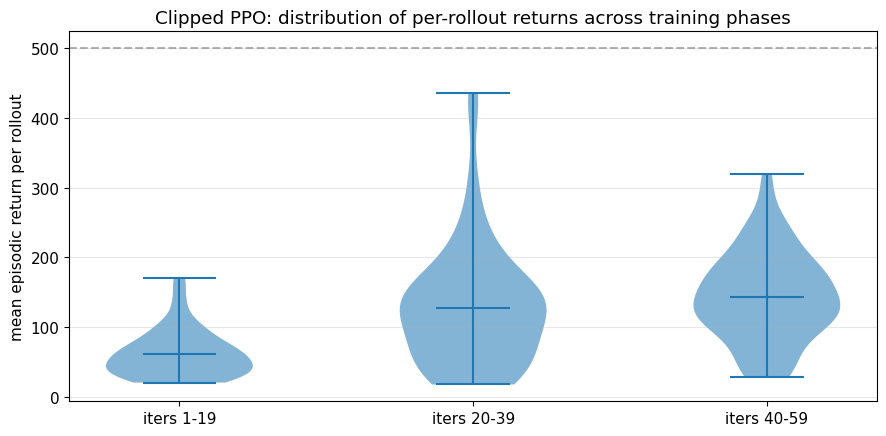

In [28]:
# Violin plot: distribution of (mean_return) across iterations, in three training phases
all_means = np.concatenate([np.array(r["hist"]["mean_return"]) for r in runs_clip])
all_iters = np.concatenate([np.array(r["hist"]["iter"]) for r in runs_clip])
max_iter = int(all_iters.max())
bins = [(1, max_iter // 3),
        (max_iter // 3 + 1, 2 * max_iter // 3),
        (2 * max_iter // 3 + 1, max_iter)]
groups = []
labels = []
for lo, hi in bins:
    mask = (all_iters >= lo) & (all_iters <= hi)
    groups.append(all_means[mask])
    labels.append(f"iters {lo}-{hi}")

fig, ax = plt.subplots(figsize=(9, 4.5))
parts = ax.violinplot(groups, showmeans=True, showmedians=False)
for pc in parts["bodies"]:
    pc.set_alpha(0.55); pc.set_facecolor("tab:blue")
ax.set_xticks(range(1, len(labels) + 1)); ax.set_xticklabels(labels)
ax.axhline(500, ls="--", color="gray", alpha=0.6)
ax.set_ylabel("mean episodic return per rollout")
ax.set_title("Clipped PPO: distribution of per-rollout returns across training phases")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## Learned value function $V_\phi(s)$

CartPole has a 4-dim state. We visualize the critic's output as a 2D slice holding cart position and cart velocity at zero, sweeping pole angle and pole angular velocity. In a well-trained agent we expect $V(s)$ to be high near the origin (pole upright and still) and drop off as the pole tilts or spins fast, since those states are closer to episode termination.

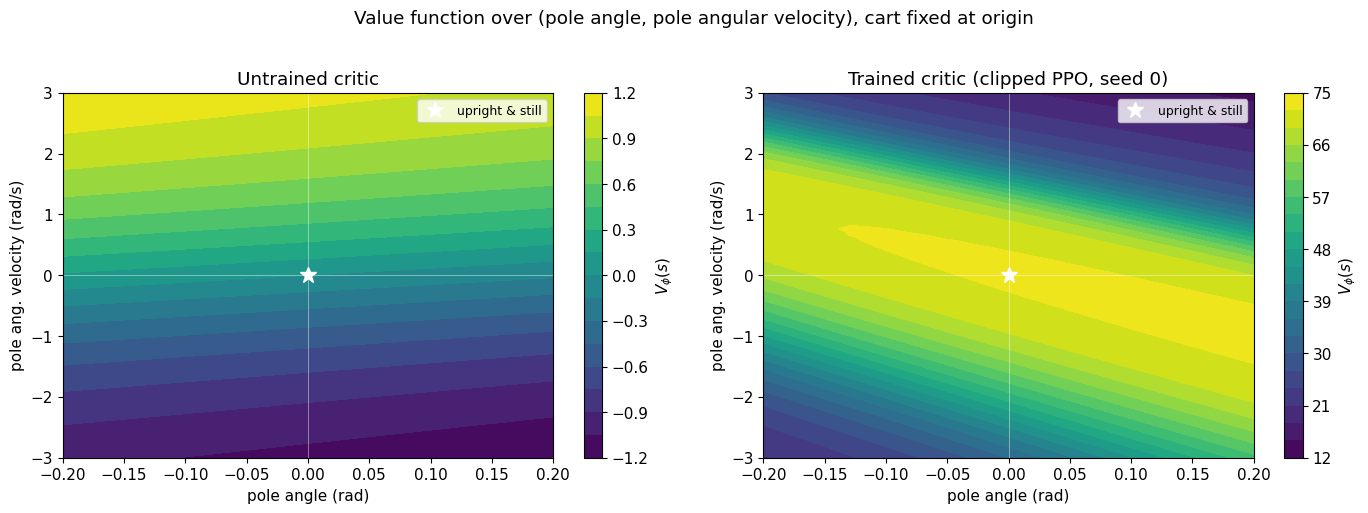

In [29]:
def value_heatmap(model, angle_range=(-0.2, 0.2), angvel_range=(-3.0, 3.0),
                  grid=60, cart_pos=0.0, cart_vel=0.0):
    angles  = np.linspace(*angle_range, grid)
    angvels = np.linspace(*angvel_range, grid)
    A, W = np.meshgrid(angles, angvels, indexing="xy")
    S = np.stack([np.full_like(A, cart_pos), np.full_like(A, cart_vel), A, W], axis=-1)
    S_t = torch.as_tensor(S.reshape(-1, 4), dtype=torch.float32)
    with torch.no_grad():
        _, V = model.forward(S_t)
    return A, W, V.numpy().reshape(grid, grid)

# Pick the best clipped seed (reused below for rendering, too)
best_idx = int(np.argmax([r["hist"]["mean_return"][-1] for r in runs_clip]))
best_model = runs_clip[best_idx]["model"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
untrained = ActorCritic(4, 2)
A, W, V0 = value_heatmap(untrained)
A, W, V1 = value_heatmap(best_model)

im0 = axes[0].contourf(A, W, V0, levels=20, cmap="viridis")
axes[0].set_title("Untrained critic")
axes[0].set_xlabel("pole angle (rad)"); axes[0].set_ylabel("pole ang. velocity (rad/s)")
plt.colorbar(im0, ax=axes[0], label=r"$V_\phi(s)$")

im1 = axes[1].contourf(A, W, V1, levels=20, cmap="viridis")
axes[1].set_title(f"Trained critic (clipped PPO, seed {runs_clip[best_idx]['seed']})")
axes[1].set_xlabel("pole angle (rad)"); axes[1].set_ylabel("pole ang. velocity (rad/s)")
plt.colorbar(im1, ax=axes[1], label=r"$V_\phi(s)$")

for ax in axes:
    ax.axhline(0, color="white", lw=0.5, alpha=0.6)
    ax.axvline(0, color="white", lw=0.5, alpha=0.6)
    ax.plot(0, 0, "w*", ms=12, label="upright & still")
    ax.legend(loc="upper right", fontsize=9)
plt.suptitle("Value function over (pole angle, pole angular velocity), cart fixed at origin",
             y=1.02)
plt.tight_layout(); plt.show()

The trained critic assigns the highest value to states near the origin (pole upright, low angular velocity) and drops off as the pole tilts or spins, since those states are closer to failure. The untrained critic, by contrast, is essentially flat: it hasn't seen any data yet and its output is the output of random initialization.

## Rendering the trained policy

"Rendering" here means asking Gymnasium to draw the current state of the environment as an image at each step. We create the env with `render_mode="rgb_array"`, which makes `env.render()` return an `(H, W, 3)` numpy array of pixels. We pick the best clipped-PPO seed, roll out one greedy episode, collect the frames, and save them as a GIF with `imageio.mimsave`. The result displays inline right below.

In [30]:
def evaluate_and_record(model, env_name="CartPole-v1", max_steps=500,
                        gif_path="trained_agent.gif", greedy=True, seed=123):
    env = gym.make(env_name, render_mode="rgb_array")
    obs, _ = env.reset(seed=seed)
    frames, ep_ret, steps, done = [], 0.0, 0, False
    while not done and steps < max_steps:
        frames.append(env.render())
        obs_t = torch.as_tensor(obs, dtype=torch.float32)
        with torch.no_grad():
            logits, _ = model.forward(obs_t)
            a = int(torch.argmax(logits).item()) if greedy else int(Categorical(logits=logits).sample().item())
        obs, r, term, trunc, _ = env.step(a)
        done = term or trunc
        ep_ret += r; steps += 1
    env.close()
    imageio.mimsave(gif_path, frames, fps=30)
    return frames, ep_ret

# best_idx and best_model were set in the value-heatmap cell above
print(f"clipped seed={runs_clip[best_idx]['seed']}, "
      f"final training return={runs_clip[best_idx]['hist']['mean_return'][-1]:.1f}")

frames, ep_ret = evaluate_and_record(best_model, gif_path="clipped_agent.gif")
print(f"rendered {len(frames)} frames, evaluation return = {ep_ret:.1f}")

clipped seed=0, final training return=166.6
rendered 176 frames, evaluation return = 176.0


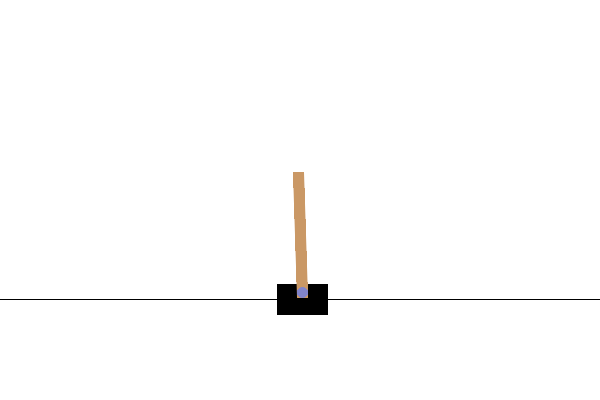

In [31]:
from IPython.display import Image, display
display(Image(filename="clipped_agent.gif"))

unclipped seed=0, evaluation return = 500.0


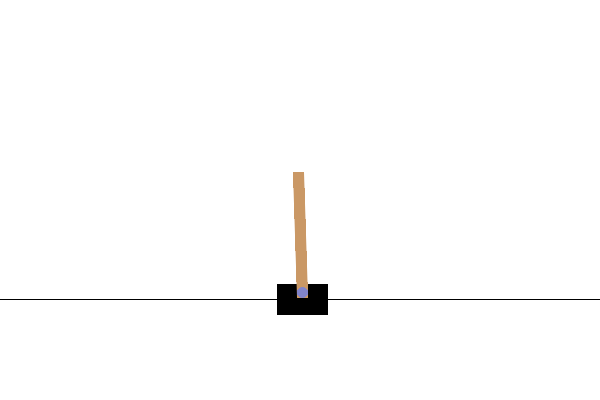

In [32]:
best_idx_u = int(np.argmax([r["hist"]["mean_return"][-1] for r in runs_noclip]))
best_model_u = runs_noclip[best_idx_u]["model"]
frames_u, ret_u = evaluate_and_record(best_model_u, gif_path="unclipped_agent.gif", seed=123)
print(f"unclipped seed={runs_noclip[best_idx_u]['seed']}, evaluation return = {ret_u:.1f}")
display(Image(filename="unclipped_agent.gif"))

A static filmstrip of the clipped-agent episode, in case the GIF above does not render:

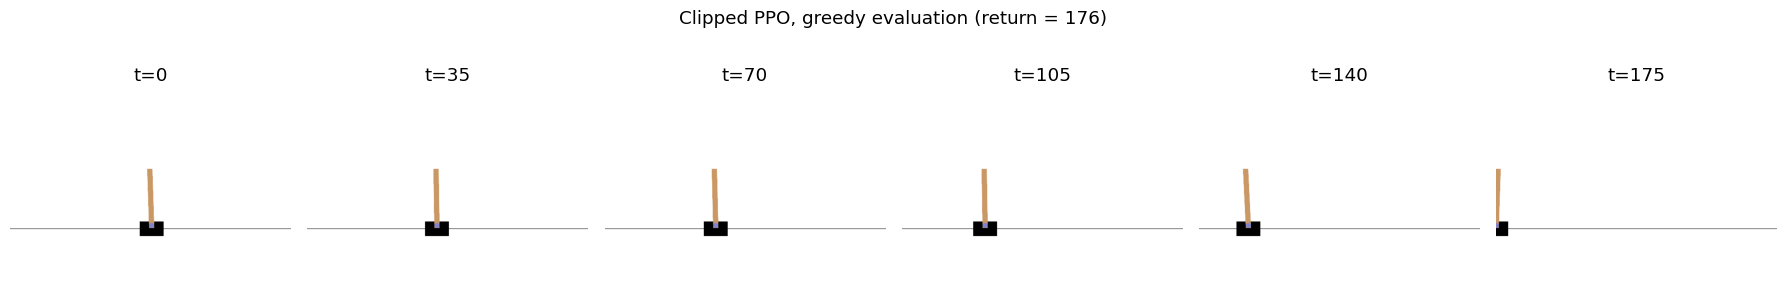

In [33]:
n_show = min(6, len(frames))
idxs = np.linspace(0, len(frames) - 1, n_show).astype(int)
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1: axes = [axes]
for ax, i in zip(axes, idxs):
    ax.imshow(frames[i]); ax.set_title(f"t={i}"); ax.axis("off")
plt.suptitle(f"Clipped PPO, greedy evaluation (return = {ep_ret:.0f})", y=1.02)
plt.tight_layout(); plt.show()

## Progression: untrained, mid-training, fully trained

A single GIF of a trained agent does not tell the whole story. What we actually want to visualize is how the agent changes over training: how long a fresh, untrained policy survives, how long a partially-trained one lasts, and what happens once we run the full training budget. We train one fresh agent with checkpointing, render a greedy rollout from each checkpoint under a fixed evaluation seed, and stitch them into a single progression GIF. Greedy-evaluation returns from a single seed can be noisy even as the training-time mean return improves, so the progression need not be monotonic; we will revisit this point once the numbers are in.

In [34]:
import copy

def train_with_checkpoints(checkpoint_steps, **kwargs):
    """Like train_ppo, but also return deep-copied model snapshots at each
    checkpoint step threshold (the first rollout whose cumulative steps reach it)."""
    torch.manual_seed(kwargs.get("seed", 0)); np.random.seed(kwargs.get("seed", 0))
    env = gym.make(kwargs.get("env_name", "CartPole-v1"))
    env.reset(seed=kwargs.get("seed", 0)); env.action_space.seed(kwargs.get("seed", 0))

    model = ActorCritic(env.observation_space.shape[0], env.action_space.n)
    optimizer = optim.Adam(model.parameters(), lr=kwargs.get("lr", 3e-4))

    # Snapshot of the fresh, untrained network
    snapshots = {0: copy.deepcopy(model)}
    todo = sorted(set(checkpoint_steps))
    history = {"steps": [], "mean_return": []}

    steps_done = 0
    while steps_done < kwargs.get("total_steps", 60_000):
        batch = collect_rollouts(env, model, kwargs.get("steps_per_rollout", 1024))
        advs, rets = compute_gae(batch["rews"], batch["vals"], batch["dones"],
                                 batch["last_val"],
                                 gamma=kwargs.get("gamma", 0.99),
                                 lam=kwargs.get("lam", 0.95))
        batch["advs"], batch["rets"] = advs, rets
        ppo_update(model, optimizer, batch,
                   clip_eps=kwargs.get("clip_eps", 0.2),
                   n_epochs=kwargs.get("n_epochs", 10),
                   minibatch=kwargs.get("minibatch", 64),
                   ent_coef=kwargs.get("ent_coef", 0.0),
                   use_clip=True)
        steps_done += kwargs.get("steps_per_rollout", 1024)
        mean_ret = float(np.mean(batch["ep_returns"])) if batch["ep_returns"] else 0.0
        history["steps"].append(steps_done); history["mean_return"].append(mean_ret)

        while todo and steps_done >= todo[0]:
            snapshots[todo.pop(0)] = copy.deepcopy(model)

    env.close()
    return snapshots, history

CHECKPOINTS = [0, 8_000, 20_000, 60_000]
snapshots, prog_hist = train_with_checkpoints(
    checkpoint_steps=CHECKPOINTS,
    total_steps=60_000, steps_per_rollout=1024,
    seed=0, clip_eps=0.2, lr=3e-4, gamma=0.99, lam=0.95,
    n_epochs=10, minibatch=64, ent_coef=0.0,
)
print("snapshots at steps:", sorted(snapshots.keys()))

snapshots at steps: [0, 8000, 20000, 60000]


In [35]:
def render_episode(model, seed=42, max_steps=500, env_name="CartPole-v1"):
    """Roll out one greedy episode and return the list of RGB frames + the return."""
    env = gym.make(env_name, render_mode="rgb_array")
    obs, _ = env.reset(seed=seed)
    frames, ep_ret, steps, done = [], 0.0, 0, False
    while not done and steps < max_steps:
        frames.append(env.render())
        obs_t = torch.as_tensor(obs, dtype=torch.float32)
        with torch.no_grad():
            logits, _ = model.forward(obs_t)
            a = int(torch.argmax(logits).item())
        obs, r, term, trunc, _ = env.step(a)
        done = term or trunc
        ep_ret += r; steps += 1
    env.close()
    return frames, ep_ret

# Render each checkpoint
checkpoint_rollouts = {}
for step, model in sorted(snapshots.items()):
    f, r = render_episode(model, seed=42)
    checkpoint_rollouts[step] = (f, r)
    print(f"step {step:>6d}: survived {int(r):>3d} steps")

step      0: survived 103 steps
step   8000: survived 198 steps
step  20000: survived  19 steps
step  60000: survived 182 steps


In [36]:
# Add a simple text banner to each frame so the progression GIF is self-explanatory
try:
    from PIL import Image as PILImage, ImageDraw, ImageFont
    HAS_PIL = True
except ImportError:
    HAS_PIL = False

def annotate_frames(frames, text):
    """Overlay `text` on the top-left of every frame."""
    if not HAS_PIL:
        return frames
    out = []
    for frame in frames:
        img = PILImage.fromarray(frame).copy()
        draw = ImageDraw.Draw(img)
        # Draw a translucent white rectangle behind the text for readability
        draw.rectangle([(0, 0), (320, 36)], fill=(255, 255, 255, 200))
        draw.text((8, 8), text, fill=(0, 0, 0))
        out.append(np.array(img))
    return out

# Build one concatenated frame list that walks through the checkpoints in order.
# Between clips we add a half-second of the final frame so the viewer can see the collapse.
progression_frames = []
for step in sorted(checkpoint_rollouts):
    frames_s, ret = checkpoint_rollouts[step]
    label = f"steps trained: {step:>6d}   return: {int(ret):>3d} / 500"
    progression_frames.extend(annotate_frames(frames_s, label))
    # hold the last frame for ~0.5 s at 30 fps
    progression_frames.extend([progression_frames[-1]] * 15)

imageio.mimsave("progression.gif", progression_frames, fps=30)
print(f"progression GIF: {len(progression_frames)} frames "
      f"({len(progression_frames) / 30:.1f} s at 30 fps)")

progression GIF: 562 frames (18.7 s at 30 fps)


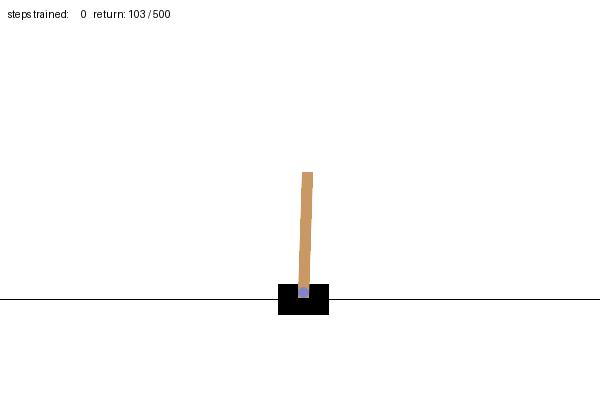

In [37]:
display(Image(filename="progression.gif"))

A static filmstrip comparing one frame from each checkpoint:

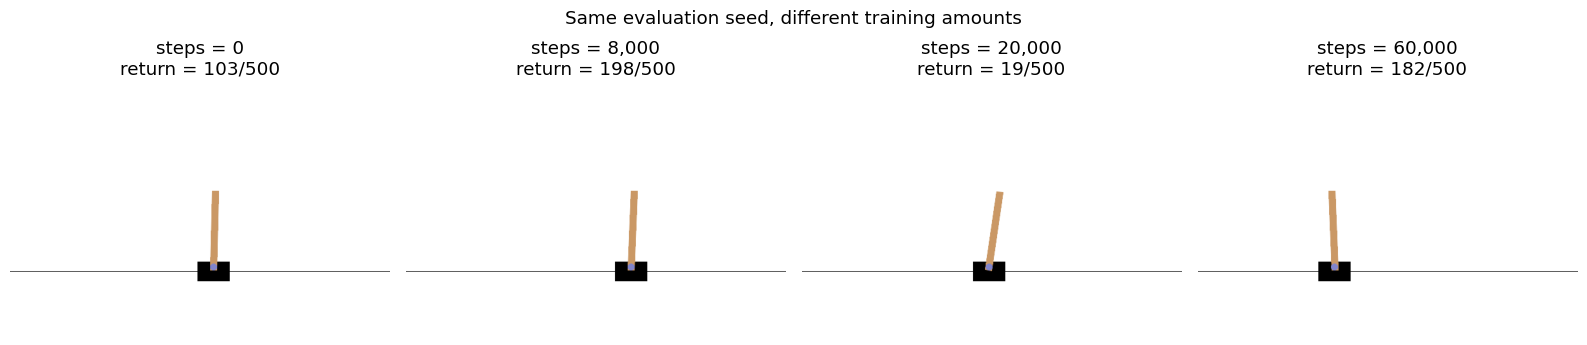

In [38]:
fig, axes = plt.subplots(1, len(checkpoint_rollouts), figsize=(4 * len(checkpoint_rollouts), 3.5))
for ax, (step, (frames_s, ret)) in zip(axes, sorted(checkpoint_rollouts.items())):
    # Pick the middle frame, or the last one if the episode was very short
    idx = min(len(frames_s) // 2, len(frames_s) - 1)
    ax.imshow(frames_s[idx])
    ax.set_title(f"steps = {step:,}\nreturn = {int(ret)}/500")
    ax.axis("off")
plt.suptitle("Same evaluation seed, different training amounts", y=1.02)
plt.tight_layout(); plt.show()

## Summary

On CartPole-v1 with matched hyperparameters, the clipped PPO agent produces a much tighter across-seed band than the unclipped variant (across-seed std $10.4$ vs.\ $175.4$ at the final iteration). The unclipped variant reaches a higher mean return in this particular 60k-step budget (376.0 vs.\ 152.8) because some seeds happen to hit the 500-return cap, but other seeds collapse, which is exactly the failure mode the clip is designed to prevent. The diagnostics trace this to per-update KL: the clip keeps it in a narrow healthy band, the unclipped surrogate lets it spike. In a setting where predictability across runs matters more than a single lucky rollout, the clipped variant is clearly preferable.

The hyperparameter sweeps are single-seed at 40k steps and therefore noisy; readers should treat the individual final-return numbers as noisy samples rather than precise rankings. Two sweeps produced clean monotonic trends within the ranges tested: learning rate (higher is better at this budget, with $3\mathrm{e}{-3}$ hitting the cap) and PPO epochs (more is better, with $K=20$ giving the highest final return). Three sweeps did not produce a clean monotonic ranking: clip $\varepsilon$ (non-monotonic, with $\varepsilon=0.5$ happening to top the table), GAE $\lambda$ (with $\lambda=0$ happening to do best), and entropy coefficient (with $c_e=0$ best among tested values and larger values clearly degrading performance). We read this as a property of the evaluation protocol rather than a challenge to the standard PPO folklore: a single seed at 40k steps on CartPole is not enough to separate small hyperparameter effects from run-to-run noise, and the standard defaults ($\varepsilon=0.2$, $\lambda=0.95$, $c_e=0$) are widely reported as robust on harder tasks.

The value-function heatmap confirms the critic learned a sensible landscape, with $V_\phi(s)$ peaking near the upright-and-still state and decaying as the pole tilts or spins. The rendered GIFs give the qualitative confirmation. Greedy evaluation of the best clipped-PPO seed survives 176 steps against evaluation seed 123; the best unclipped seed survives the full 500 on the same evaluation seed. The progression GIF, which rolls out checkpoints of a single training run at a fixed evaluation seed, shows that single-seed greedy evaluation is itself noisy: the untrained policy happens to survive 103 steps, the 8k-step checkpoint 198, the 20k-step checkpoint only 19 (a local regression that lines up with a KL spike in the training log), and the 60k-step checkpoint 182. This is a useful reminder that per-rollout training returns and single-seed greedy evaluations are both noisy proxies for the policy's true quality.